In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
#read the parquet files
summary_df = pd.read_parquet('grid_search_summary_8.parquet')
coefficients_df = pd.read_parquet('grid_search_coefficients_8.parquet')

In [8]:
summary_df.head()

,window_size,n_lags,lambda,r2_insample_stage1,r2_oos_stage1,r2_insample_stage2,r2_oos_stage2,kappa,kappa_tstat,intercept,intercept_tstat,n_observations,n_windows,n_oos_predictions_stage2,target
0,200,6,0.003587,-0.001363,-0.002352,8.948582e-08,0.005022,2.211961e-04,6.460978e-05,0.000424,1.893701,1682,1683,1581,0.0
1,200,8,0.003587,-0.000984,-0.002300,-6.825309e-10,0.004950,3.119035e-08,1.565598e-08,0.000426,1.900874,1680,1681,1579,-0.0
2,200,7,0.003587,-0.000984,-0.002301,-7.500278e-08,0.004947,3.119249e-08,1.566113e-08,0.000425,1.893656,1681,1682,1580,-0.0
3,60,6,0.005671,0.010652,-0.005343,-1.042423e-08,0.003751,3.306806e-08,2.283690e-07,0.000393,1.753528,1822,1823,1721,-0.0
4,60,6,0.005209,0.018024,-0.008570,3.024046e-08,0.003574,1.673324e-06,1.359326e-05,0.000393,1.753528,1822,1823,1721,0.0


In [32]:
summary_df['target'] = summary_df['r2_insample_stage2'] * summary_df['kappa'] * [summary_df[kappa_tstat_col] > 2.0 for kappa_tstat_col in summary_df.columns if 'kappa_tstat' in kappa_tstat_col][0]

In [33]:
positive_target_df = summary_df[summary_df['target'] > 0]

In [34]:
#OLS of target on window_size, n_lags, lambda
import statsmodels.api as sm
X = summary_df[['window_size', 'n_lags', 'lambda']]
y = summary_df['target']
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 target   R-squared (uncentered):                   0.075
Model:                            OLS   Adj. R-squared (uncentered):              0.067
Method:                 Least Squares   F-statistic:                              8.625
Date:                Tue, 02 Dec 2025   Prob (F-statistic):                    1.61e-05
Time:                        15:42:49   Log-Likelihood:                          1622.0
No. Observations:                 320   AIC:                                     -3238.
Df Residuals:                     317   BIC:                                     -3227.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

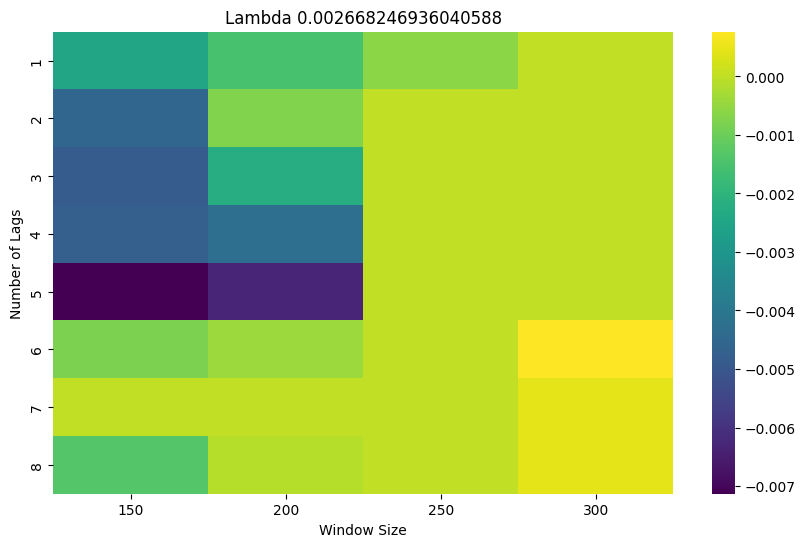

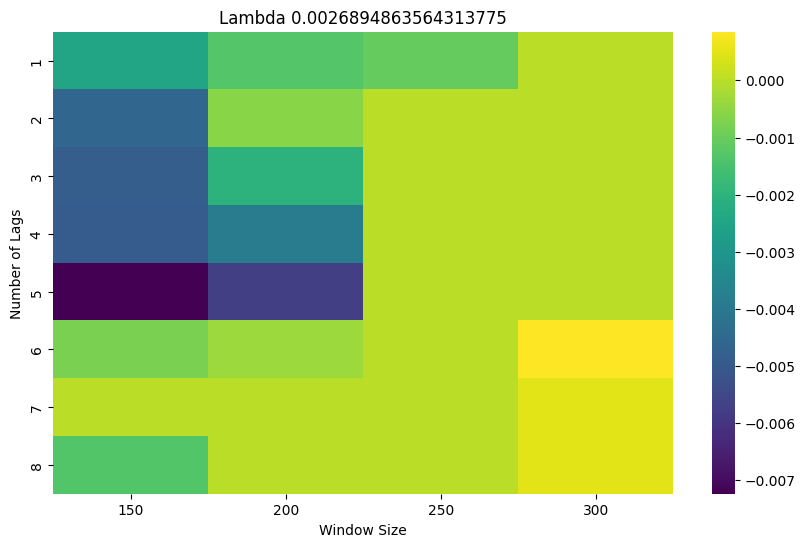

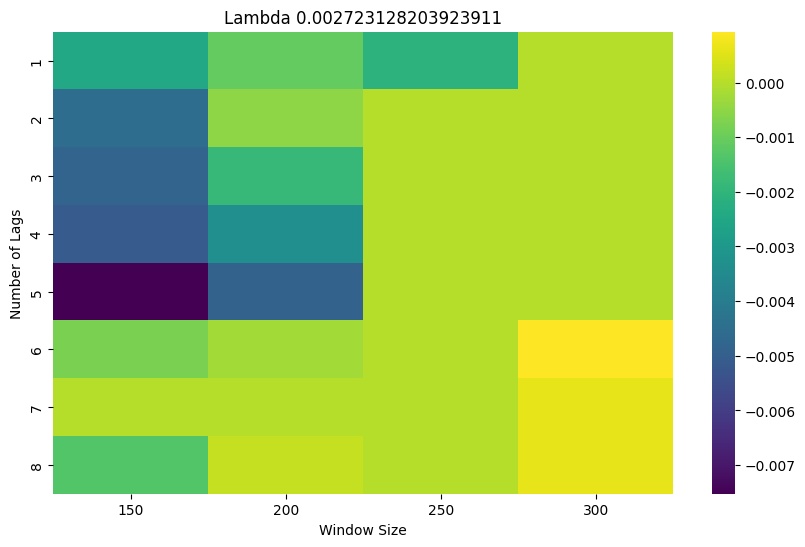

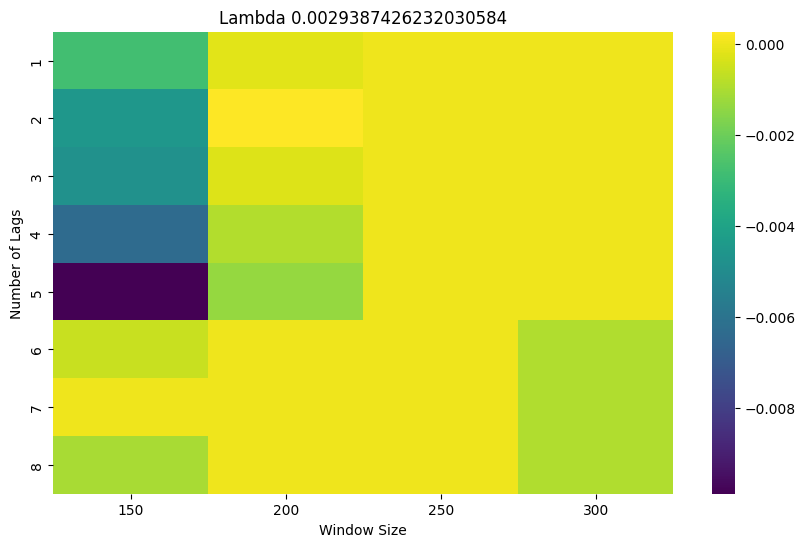

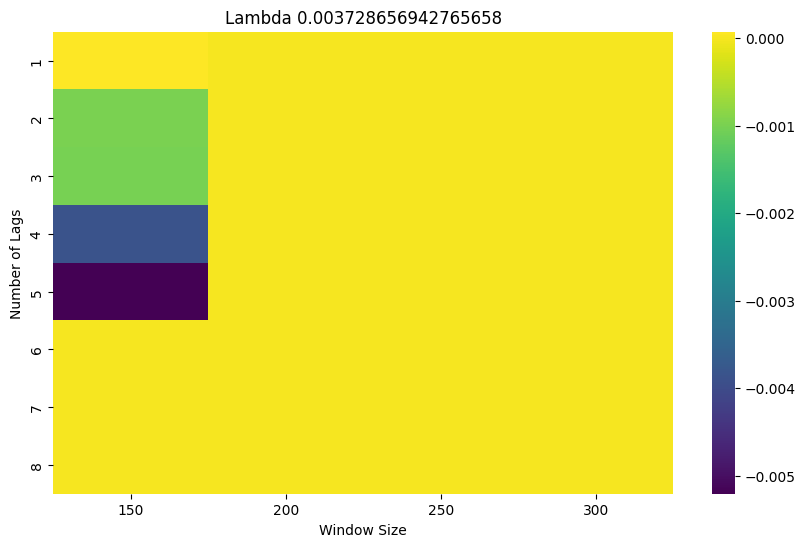

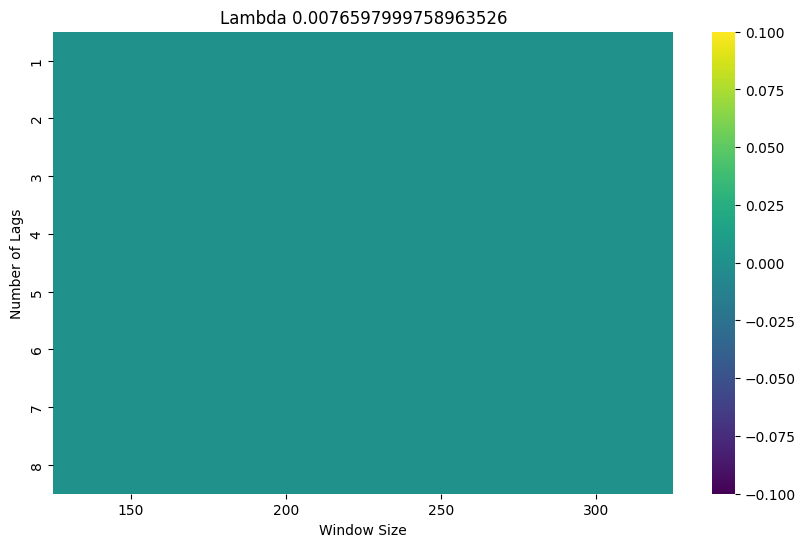

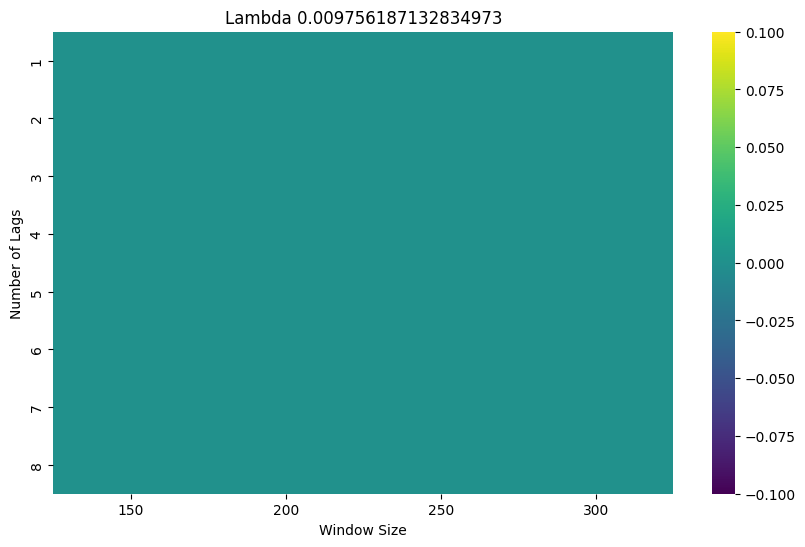

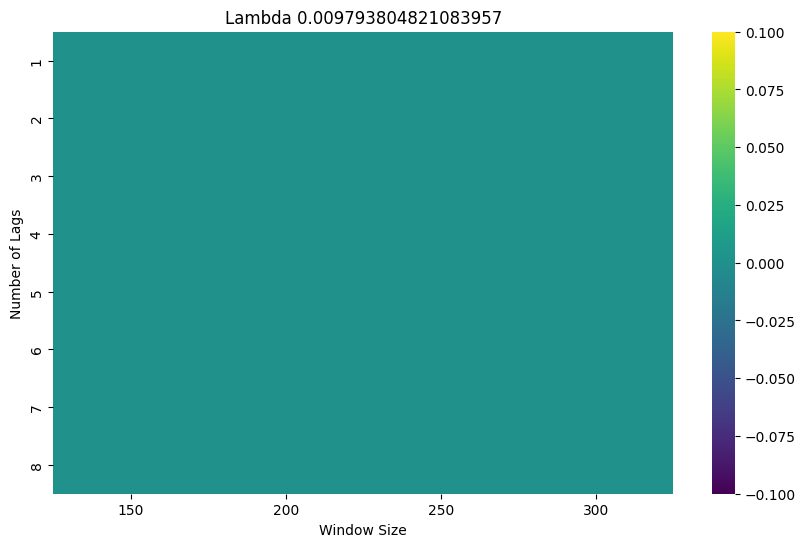

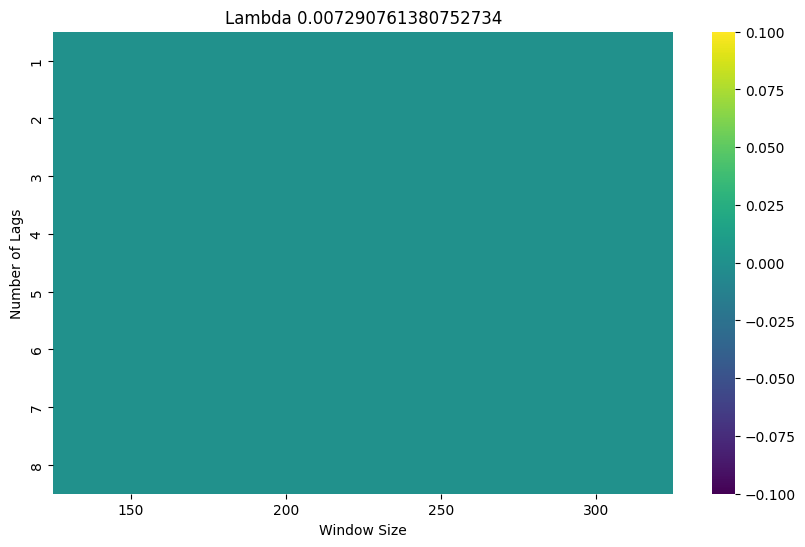

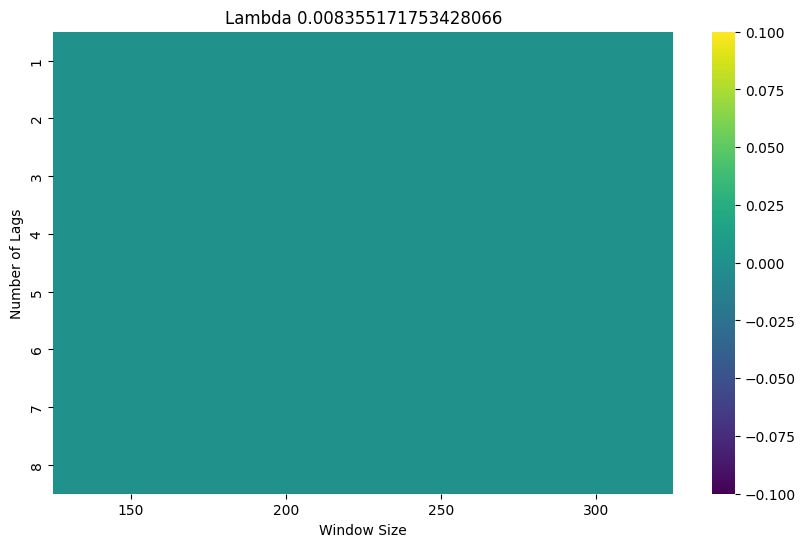

In [35]:
#for each level of the window size, plot a heatmap of the n_lags vs lambda and the target variable
for l in summary_df['lambda'].unique():
    subset = summary_df[summary_df['lambda'] == l]
    heatmap_data = subset.pivot(index ='n_lags', columns='window_size', values='target')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=False, fmt=".4f", cmap='viridis')
    plt.title(f'Lambda {l}')
    plt.xlabel('Window Size')
    plt.ylabel('Number of Lags')
    plt.show()

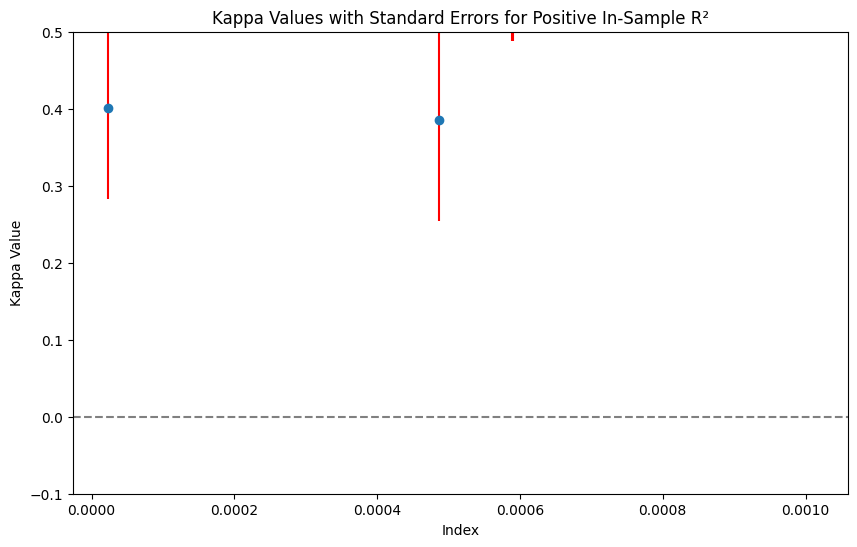

In [40]:
#for each entry in the positive r2 dataframe, plot the kappa value and standard errors
positive_target_df['kappa_se'] = positive_target_df['kappa'] / positive_target_df['kappa_tstat']
plt.figure(figsize=(10,6))
plt.errorbar(positive_target_df['r2_insample_stage2'], positive_target_df['kappa'], yerr=positive_target_df['kappa_se'], fmt='o', ecolor='r', capthick=2)
plt.axhline(0, color='gray', linestyle='--')
#ylims
plt.ylim(-0.1, 0.5)
plt.title('Kappa Values with Standard Errors for Positive In-Sample R²')
plt.xlabel('Index')
plt.ylabel('Kappa Value')
plt.show()

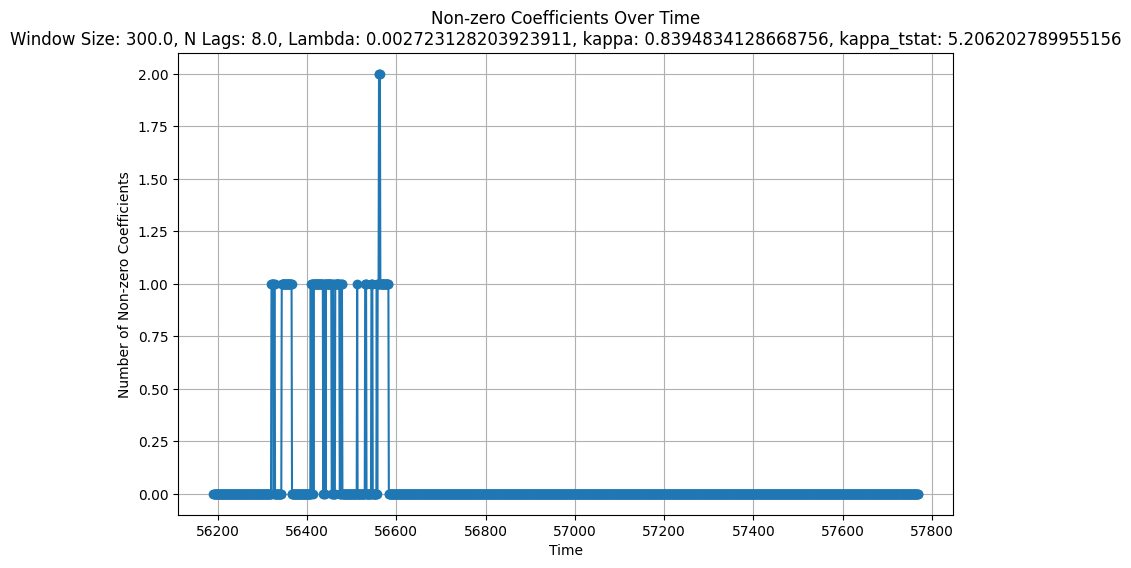

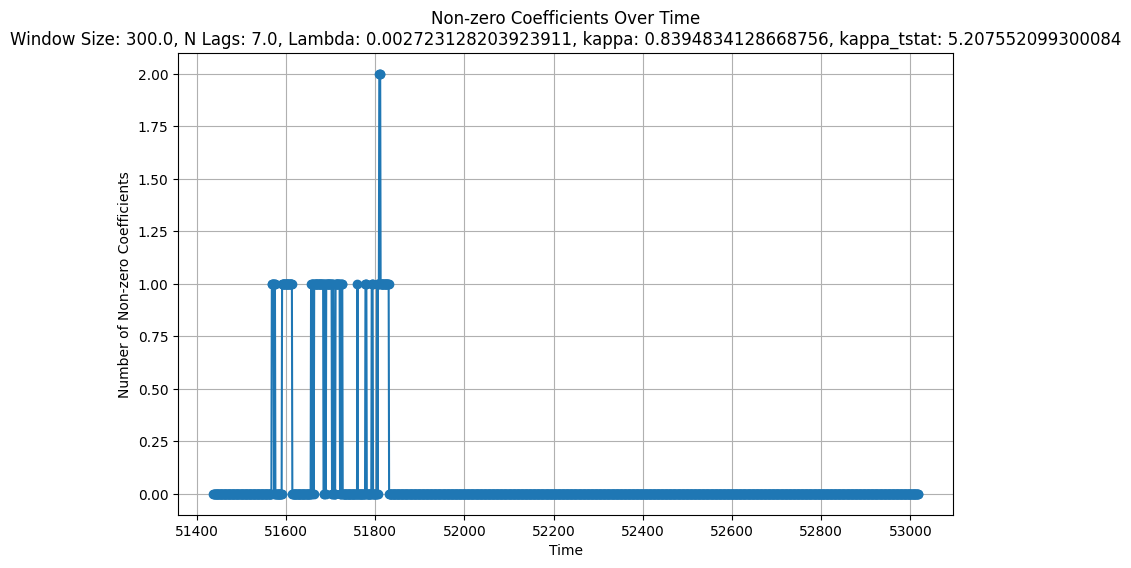

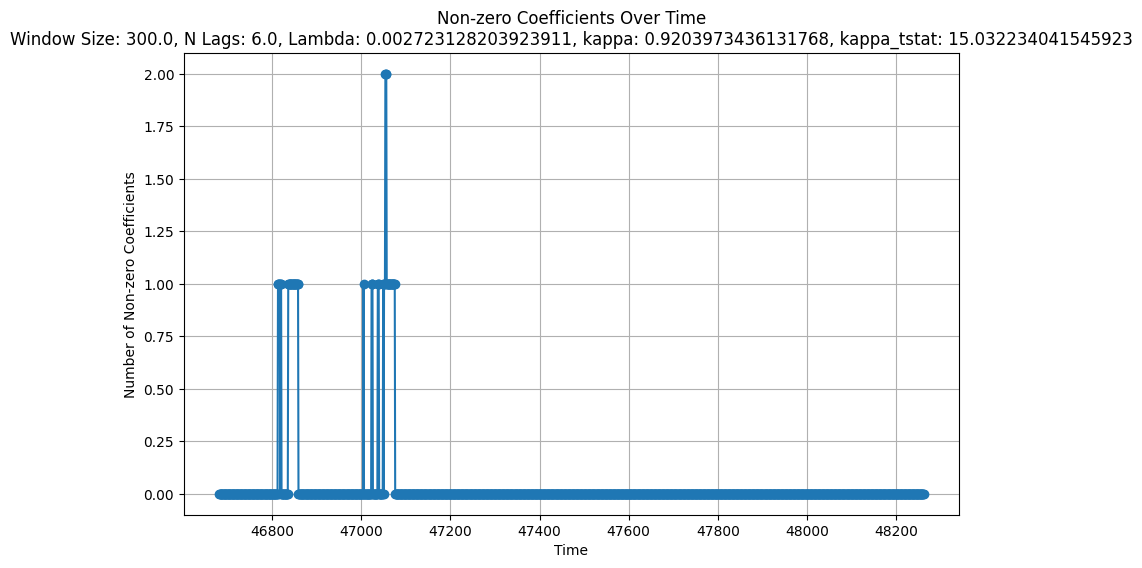

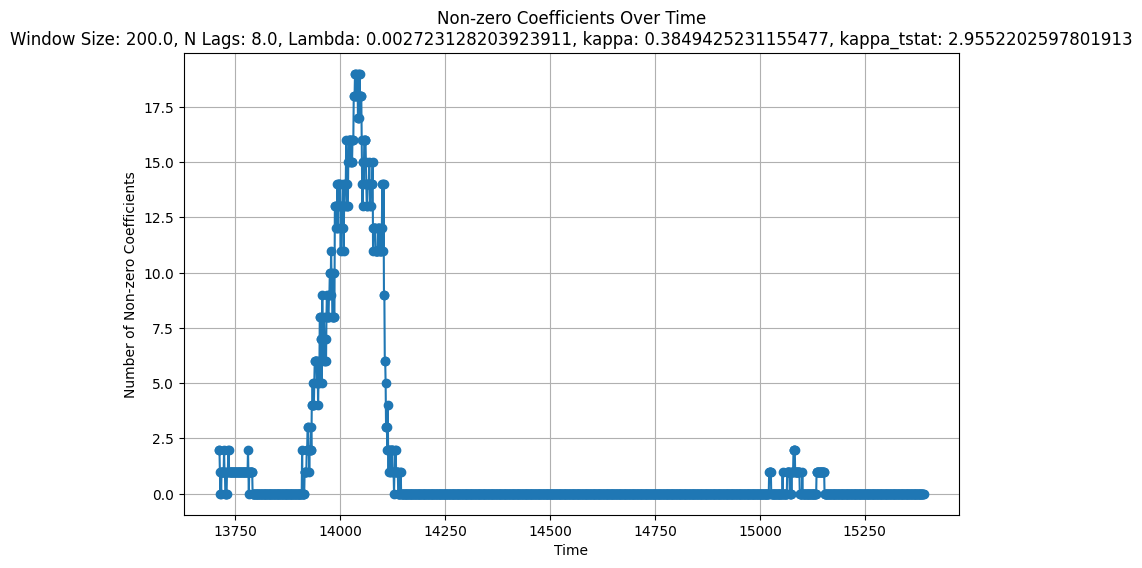

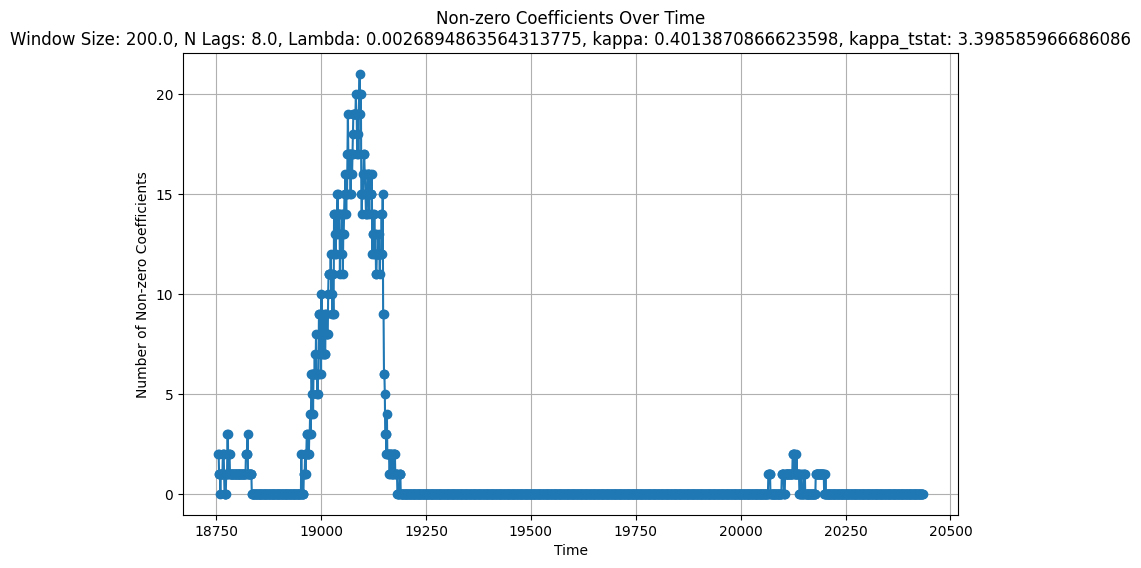

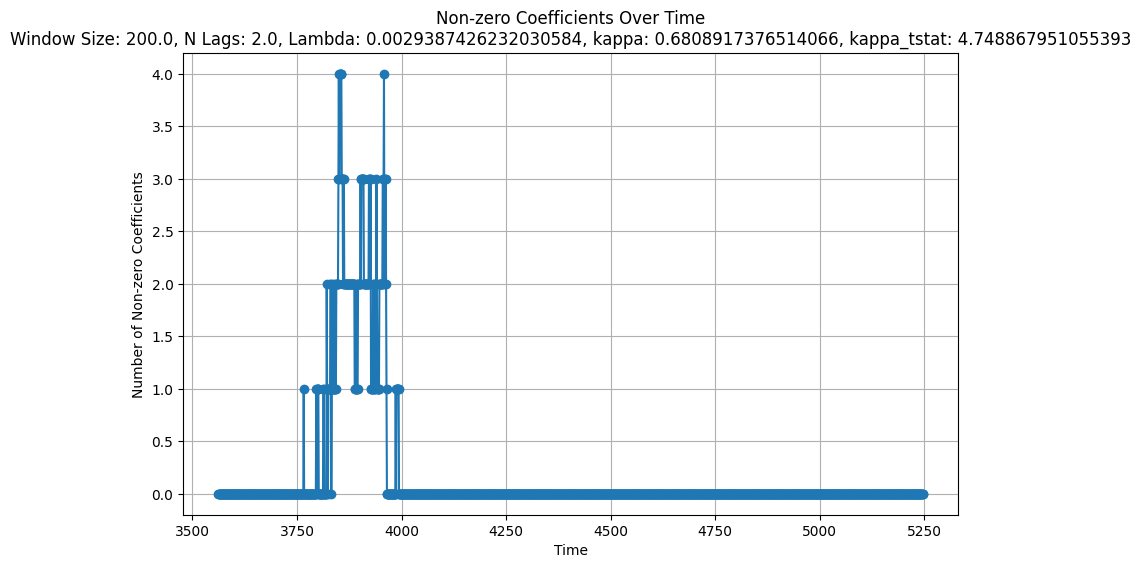

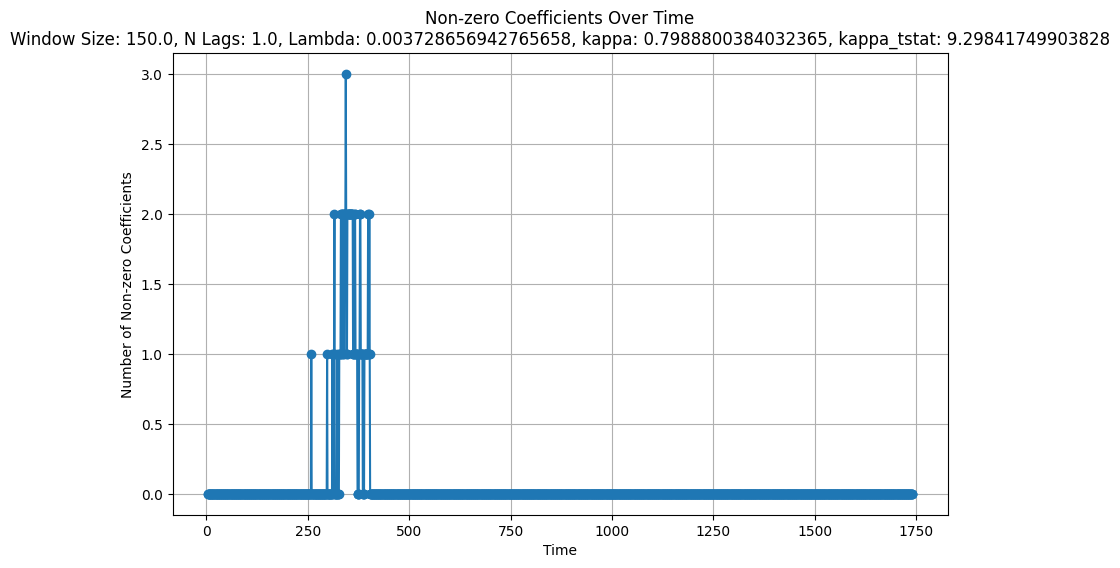

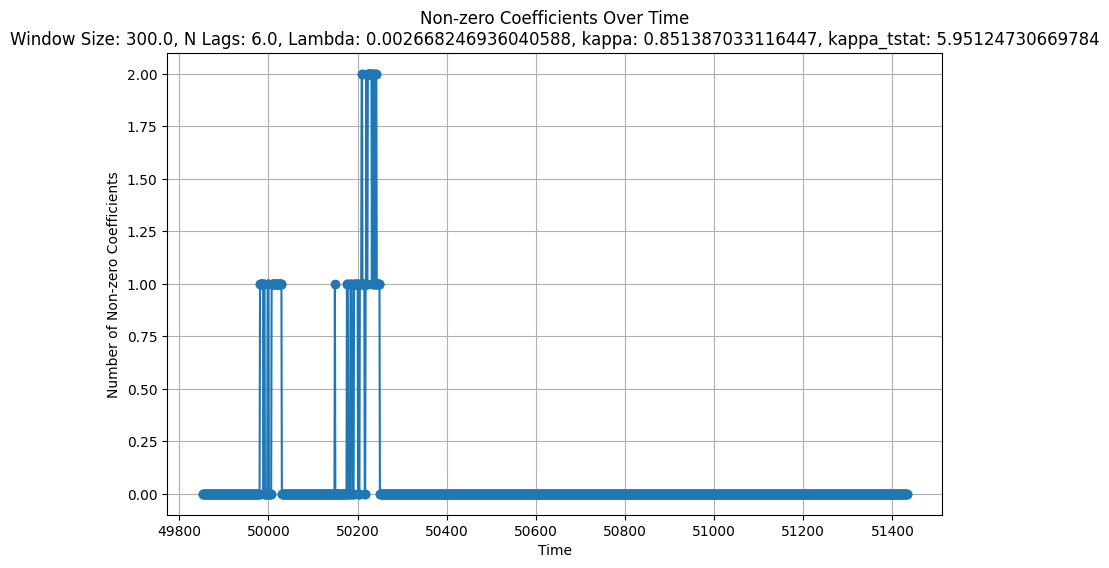

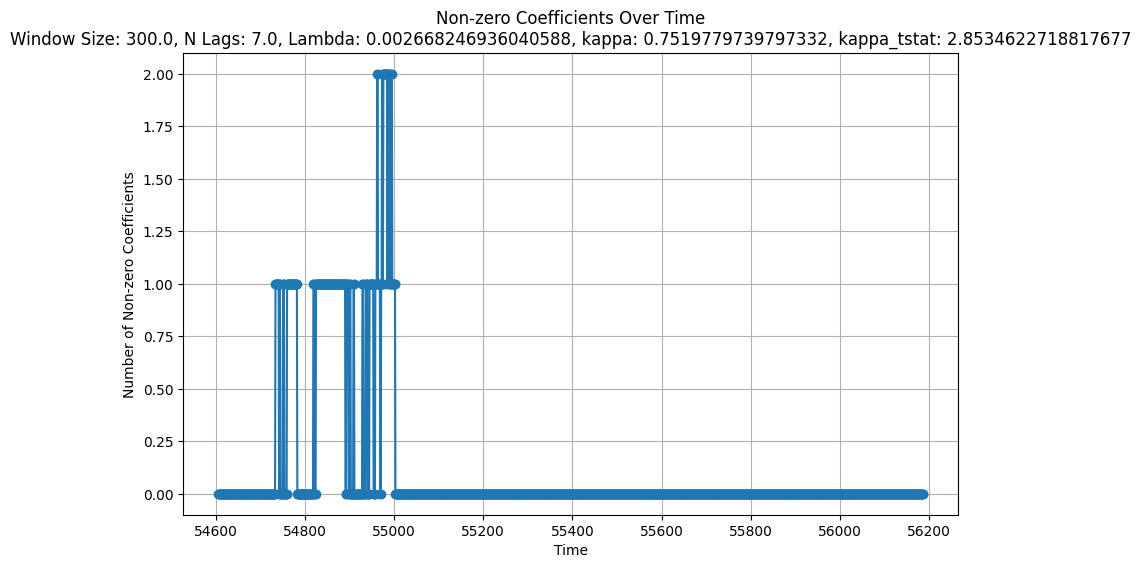

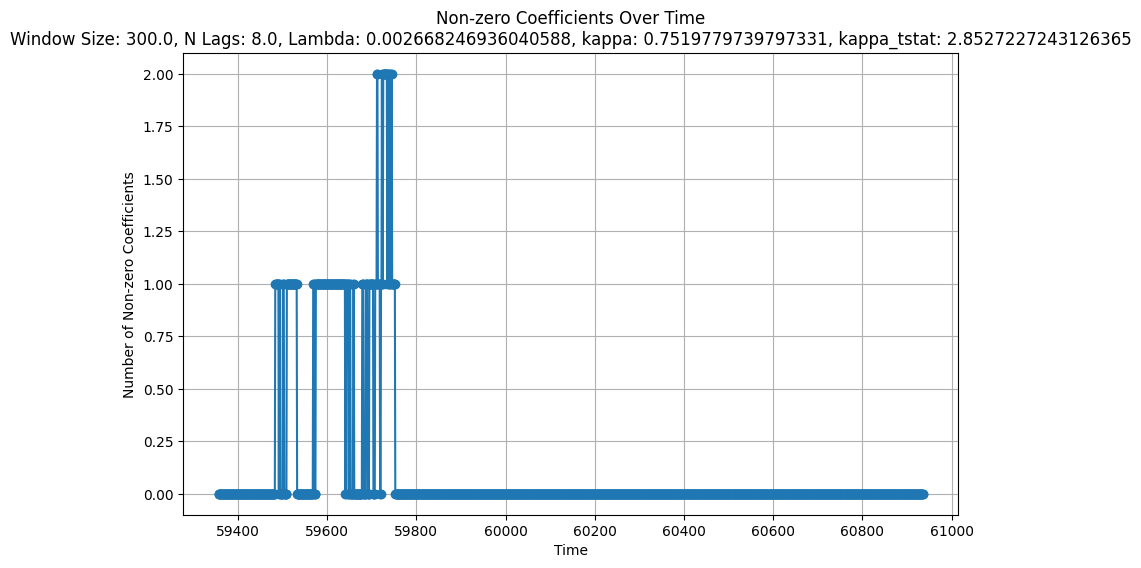

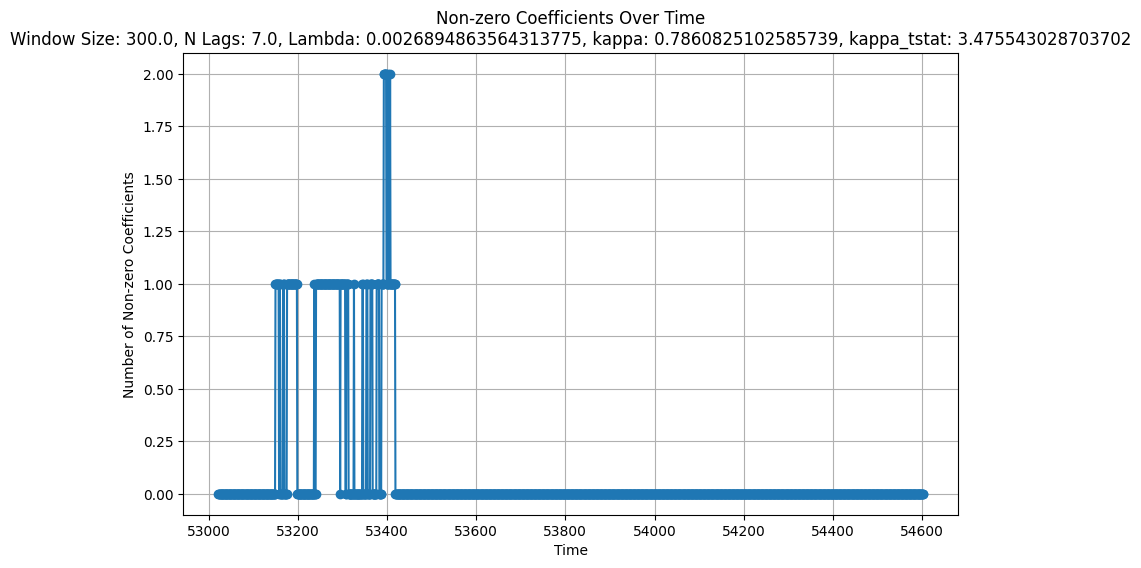

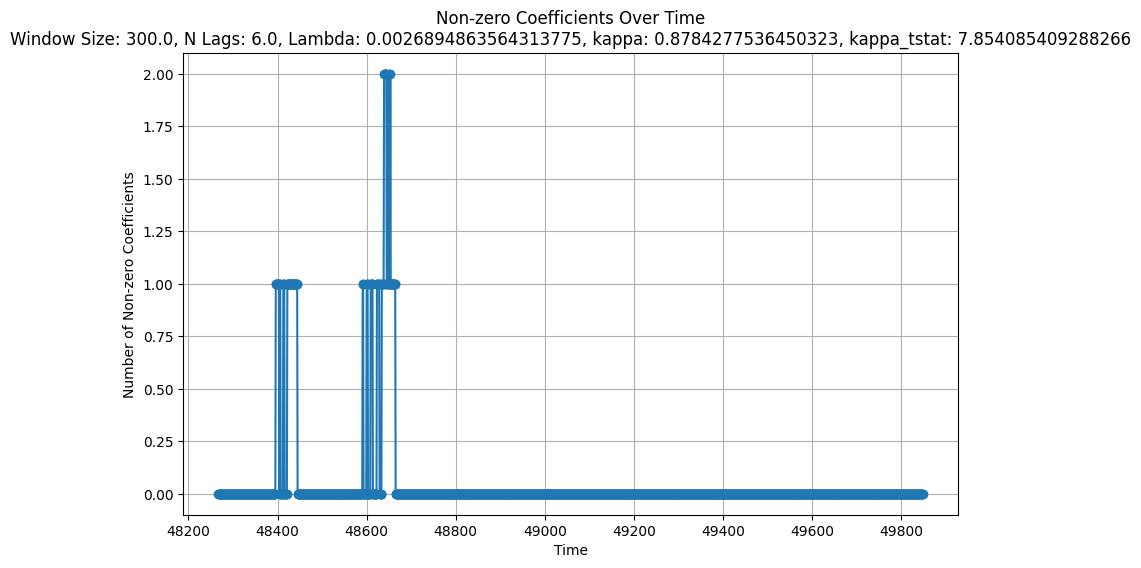

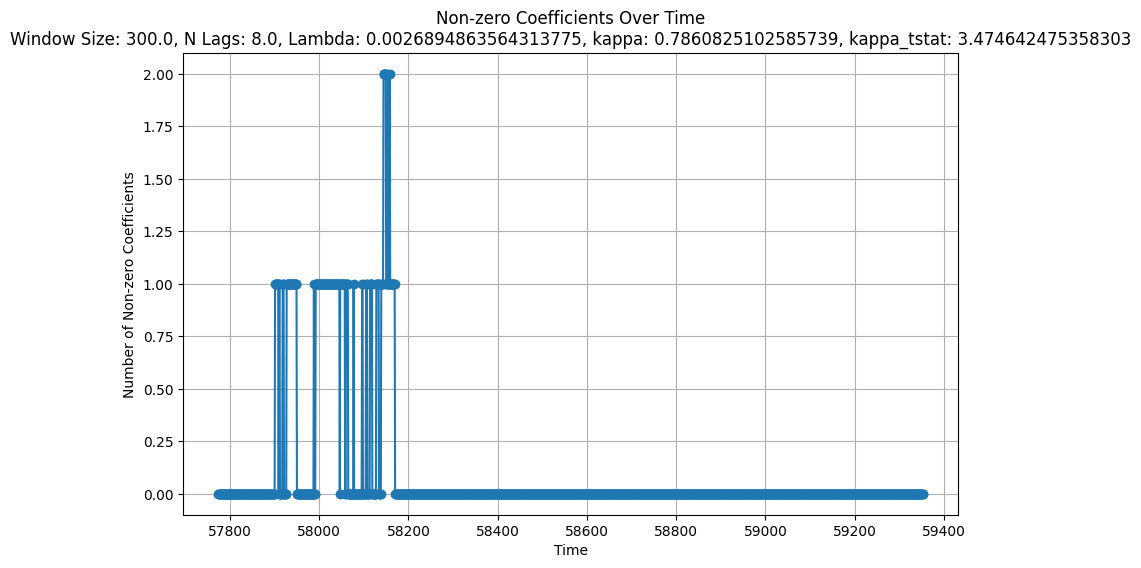

In [41]:
#for each entry in the positive r2 dataframe, plot the number of non-zero coefficients over time
for index, row in positive_target_df.iterrows():
    window_size = row['window_size']
    n_lags = row['n_lags']
    lambda_val = row['lambda']
    kappa_tstat = row['kappa_tstat']
    kappa_value = row['kappa']
    
    #filter coefficients dataframe for the current parameters
    coeffs_filtered = coefficients_df[
        (coefficients_df['window_size'] == window_size) & 
        (coefficients_df['n_lags'] == n_lags) & 
        (coefficients_df['lambda'] == lambda_val)
    ]
    
    #plot
    plt.figure(figsize=(10, 6))
    plt.plot(coeffs_filtered['num_nonzero_coefficients'], marker='o')
    plt.title(f'Non-zero Coefficients Over Time\nWindow Size: {window_size}, N Lags: {n_lags}, Lambda: {lambda_val}, kappa: {kappa_value}, kappa_tstat: {kappa_tstat}')
    plt.xlabel('Time')
    plt.ylabel('Number of Non-zero Coefficients')
    plt.grid()
    plt.show()